In [1]:
import pandas as pd

epistemic = pd.read_csv('epistemic.csv') 
recency = pd.read_csv('recency.csv')
engagement = pd.read_csv('engagement.csv')

epistemic['Feed Type'] = 'Epistemic'
recency['Feed Type'] = 'Recency'
engagement['Feed Type'] = 'Engagement'

df = pd.concat([epistemic, recency, engagement], ignore_index=True)
print(f"Total responses: {len(df)}")
print(df['Feed Type'].value_counts())

Total responses: 72
Feed Type
Epistemic     27
Recency       23
Engagement    22
Name: count, dtype: int64


In [2]:
# First let's see the actual column names from your survey export
print(df.columns.tolist())

['Timestamp', 'Feed Type', 'Articles Shown', 'Q1: Familiarity', 'Q2: Prior Knowledge', 'Q3: News Source', 'Q4: International News Frequency', 'Q5: Posts Read Count', 'Q6: Saw Ads', 'Q7: Answer', 'Q7: Confidence', 'Q8: Answer', 'Q8: Confidence', 'Q9: Answer', 'Q9: Confidence', 'Q10: Answer', 'Q10: Confidence', 'Q11: Answer', 'Q11: Confidence', 'Q12: Answer', 'Q12: Confidence', 'Q13: Answer', 'Q13: Confidence', 'Q14: Answer', 'Q14: Confidence', 'Q15: Answer', 'Q15: Confidence', 'Q16: Answer', 'Q16: Confidence', 'Q17: Trust', 'Q18: Bias', 'Q19: Emotion', 'Q20: Contradiction', 'Q21: Charged Language', 'Q22: Context', 'Q23: Attention', 'Q24: Age', 'Q25: Education', 'Q26: Country', 'Q27: Politics']


In [3]:
print("Sample answer values:", df['Q7: Answer'].unique())
print("Attention check values:", df['Q23: Attention'].unique())
print("Posts read values:", df['Q5: Posts Read Count'].unique())
print("Feed type values:", df['Feed Type'].unique())

Sample answer values: <StringArray>
['FALSE', 'TRUE', nan, 'NEI']
Length: 4, dtype: str
Attention check values: <StringArray>
['Somewhat agree', 'Strongly disagree', 'Agree', nan, 'Disagree']
Length: 5, dtype: str
Posts read values: <StringArray>
['1-3', '4-6', '7-10', '0', nan]
Length: 5, dtype: str
Feed type values: <StringArray>
['Epistemic', 'Recency', 'Engagement']
Length: 3, dtype: str


In [4]:
import numpy as np

# Ground truth: True = event happened, False = did not happen
ground_truth = {
    'Q7':  False,  # Shot in Bratislava — False, was Handlová
    'Q8':  True,   # Apprehended at scene
    'Q9':  True,   # Five shots
    'Q10': True,   # After cabinet meeting
    'Q11': True,   # Politically motivated
    'Q12': False,  # Died within 24hrs — False, survived
    'Q13': True,   # Suspect was 71 years old
    'Q14': True,   # Gun was legally owned
    'Q15': True,   # Biden and Putin condemned
    'Q16': False,  # PM continuously since 2006 — False
}

# Exclude attention check failures
n_before = len(df)
df = df[df['Q23: Attention'] == 'Somewhat agree'].copy()
n_after = len(df)
print(f"Excluded {n_before - n_after} attention check failures. N remaining: {n_after}")
print(df['Feed Type'].value_counts())

# Exclude participants who answered no questions 
# (all answer columns are NaN — data quality issue)
answer_cols = [f'{q}: Answer' for q in ground_truth.keys()]
df['n_answered'] = df[answer_cols].notna().sum(axis=1)
n_before_qa = len(df)
df = df[df['n_answered'] > 0].copy()
n_after_qa = len(df)
print(f"Excluded {n_before_qa - n_after_qa} participants who answered no questions.")
print(f"N remaining: {len(df)}")
print(df['Feed Type'].value_counts())

# Per-question correctness (1 = correct, 0 = incorrect, NaN = skipped)
for q, truth in ground_truth.items():
    truth_str = 'TRUE' if truth else 'FALSE'
    answer_col = f'{q}: Answer'
    correct_col = f'{q}_correct'
    df[correct_col] = np.where(
        df[answer_col].isna(), np.nan,
        (df[answer_col] == truth_str).astype(float)
    )

correct_cols = [f'{q}_correct' for q in ground_truth.keys()]

# Accuracy: mean correctness across non-skipped questions
df['accuracy'] = df[correct_cols].mean(axis=1)

# NEI rate: proportion of NEI responses per participant
for q in ground_truth.keys():
    df[f'{q}_nei'] = (df[f'{q}: Answer'] == 'NEI').astype(float)
nei_cols = [f'{q}_nei' for q in ground_truth.keys()]
df['nei_rate'] = df[nei_cols].mean(axis=1)

# Brier score
def compute_brier(row):
    scores = []
    for q, truth in ground_truth.items():
        answer = row[f'{q}: Answer']
        conf_raw = row[f'{q}: Confidence']
        if pd.isna(answer) or pd.isna(conf_raw):
            continue
        conf = float(conf_raw) / 100.0
        if answer == 'NEI':
            p_correct = 0.5
        elif (answer == 'TRUE' and truth) or (answer == 'FALSE' and not truth):
            p_correct = conf
        else:
            p_correct = 1.0 - conf
        scores.append((p_correct - 1.0) ** 2)
    return np.mean(scores) if scores else np.nan

df['brier'] = df.apply(compute_brier, axis=1)

# Posts read ordinal
posts_map = {'0': 0, '1-3': 1, '4-6': 2, '7-10': 3}
df['posts_read_ord'] = df['Q5: Posts Read Count'].map(posts_map)

# Prior knowledge flags
df['high_familiarity'] = df['Q1: Familiarity'] >= 4
df['prior_followed'] = df['Q2: Prior Knowledge'] == 'Yes'

# Summary
print("\n--- Outcome summary by feed ---")
print(df.groupby('Feed Type')[['accuracy', 'brier', 'nei_rate']].agg(['mean', 'std']).round(3))

Excluded 9 attention check failures. N remaining: 63
Feed Type
Epistemic     23
Recency       20
Engagement    20
Name: count, dtype: int64
Excluded 2 participants who answered no questions.
N remaining: 61
Feed Type
Epistemic     23
Recency       19
Engagement    19
Name: count, dtype: int64

--- Outcome summary by feed ---
           accuracy         brier        nei_rate       
               mean    std   mean    std     mean    std
Feed Type                                               
Engagement    0.453  0.171  0.274  0.073    0.337  0.263
Epistemic     0.470  0.267  0.212  0.060    0.365  0.287
Recency       0.340  0.186  0.234  0.060    0.521  0.280


In [5]:
from scipy import stats

feeds = ['Epistemic', 'Recency', 'Engagement']

print("=" * 55)
print("ANALYSIS 2 & 3: ACCURACY AND BRIER BY FEED TYPE")
print("=" * 55)

for outcome, label in [('accuracy', 'Belief Accuracy'), ('brier', 'Brier Score')]:
    groups = [df[df['Feed Type'] == t][outcome].dropna() for t in feeds]
    f, p = stats.f_oneway(*groups)
    print(f"\n{label}:")
    print(f"  F = {f:.3f}, p = {p:.3f}")
    for feed, group in zip(feeds, groups):
        print(f"  {feed}: mean={group.mean():.3f}, sd={group.std():.3f}, n={len(group)}")

    # Pairwise t-tests
    print("  Pairwise comparisons:")
    pairs = [('Epistemic','Recency'), ('Epistemic','Engagement'), ('Engagement','Recency')]
    for a, b in pairs:
        g1 = df[df['Feed Type'] == a][outcome].dropna()
        g2 = df[df['Feed Type'] == b][outcome].dropna()
        # t, p_t = stats.ttest_ind(g1, g2)
        t, p_t = stats.ttest_ind(g1, g2, equal_var=False)
        # Cohen's d
        pooled_sd = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
        d = (g1.mean() - g2.mean()) / pooled_sd
        print(f"    {a} vs {b}: t={t:.3f}, p={p_t:.3f}, d={d:.3f}")

print("\n" + "=" * 55)
print("ANALYSIS 4: NEI RATE BY FEED TYPE")
print("=" * 55)
groups = [df[df['Feed Type'] == t]['nei_rate'].dropna() for t in feeds]
f, p = stats.f_oneway(*groups)
print(f"F = {f:.3f}, p = {p:.3f}")
for feed, group in zip(feeds, groups):
    print(f"  {feed}: mean={group.mean():.3f}, sd={group.std():.3f}")

ANALYSIS 2 & 3: ACCURACY AND BRIER BY FEED TYPE

Belief Accuracy:
  F = 2.115, p = 0.130
  Epistemic: mean=0.470, sd=0.267, n=23
  Recency: mean=0.340, sd=0.186, n=19
  Engagement: mean=0.453, sd=0.171, n=19
  Pairwise comparisons:
    Epistemic vs Recency: t=1.851, p=0.072, d=0.564
    Epistemic vs Engagement: t=0.249, p=0.805, d=0.076
    Engagement vs Recency: t=1.944, p=0.060, d=0.631

Brier Score:
  F = 4.880, p = 0.011
  Epistemic: mean=0.212, sd=0.060, n=23
  Recency: mean=0.234, sd=0.060, n=19
  Engagement: mean=0.274, sd=0.073, n=19
  Pairwise comparisons:
    Epistemic vs Recency: t=-1.155, p=0.255, d=-0.358
    Epistemic vs Engagement: t=-2.961, p=0.005, d=-0.926
    Engagement vs Recency: t=1.862, p=0.071, d=0.604

ANALYSIS 4: NEI RATE BY FEED TYPE
F = 2.470, p = 0.093
  Epistemic: mean=0.365, sd=0.287
  Recency: mean=0.521, sd=0.280
  Engagement: mean=0.337, sd=0.263


In [18]:
from scipy.stats import ttest_ind
import numpy as np

print("NEI Rate — Pairwise Welch's t-tests")
print()
pairs = [
    ('Epistemic', 'Recency'),
    ('Epistemic', 'Engagement'),
    ('Engagement', 'Recency'),
]
for a, b in pairs:
    g1 = df[df['Feed Type']==a]['nei_rate'].dropna()
    g2 = df[df['Feed Type']==b]['nei_rate'].dropna()
    result = ttest_ind(g1, g2, equal_var=False)
    pooled_sd = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    d = (g1.mean() - g2.mean()) / pooled_sd
    print(f"{a} vs {b}:")
    print(f"  t({result.df:.1f}) = {result.statistic:.3f}, p = {result.pvalue:.3f}, d = {d:.3f}")

NEI Rate — Pairwise Welch's t-tests

Epistemic vs Recency:
  t(38.9) = -1.775, p = 0.084, d = -0.550
Epistemic vs Engagement:
  t(39.5) = 0.334, p = 0.740, d = 0.103
Engagement vs Recency:
  t(35.9) = -2.090, p = 0.044, d = -0.678


In [6]:
from statsmodels.stats.power import TTestIndPower

print("=" * 55)
print("POWER ANALYSIS")
print("=" * 55)
print("How many participants per cell needed to detect")
print("observed effect sizes at 80% power (alpha=0.05)?")
print()

power_analysis = TTestIndPower()
for label, d in [('Accuracy: Epistemic vs Recency', 0.545),
                 ('Accuracy: Engagement vs Recency', 0.526),
                 ('Brier: Epistemic vs Engagement', 0.806),
                 ('Brier: Epistemic vs Recency', 0.719)]:
    n_needed = power_analysis.solve_power(
        effect_size=abs(d),
        alpha=0.05,
        power=0.80,
        alternative='two-sided'
    )
    print(f"  {label}")
    print(f"    d={d:.3f} → need n={int(np.ceil(n_needed))} per cell")
    print()

print(f"Current n per cell: ~13")
print(f"Current power for Brier Epistemic vs Engagement (d=0.806):")
current_power = power_analysis.solve_power(
    effect_size=0.806,
    alpha=0.05,
    nobs1=13,
    alternative='two-sided'
)
print(f"  {current_power:.3f}")

POWER ANALYSIS
How many participants per cell needed to detect
observed effect sizes at 80% power (alpha=0.05)?

  Accuracy: Epistemic vs Recency
    d=0.545 → need n=54 per cell

  Accuracy: Engagement vs Recency
    d=0.526 → need n=58 per cell

  Brier: Epistemic vs Engagement
    d=0.806 → need n=26 per cell

  Brier: Epistemic vs Recency
    d=0.719 → need n=32 per cell

Current n per cell: ~13
Current power for Brier Epistemic vs Engagement (d=0.806):
  0.505


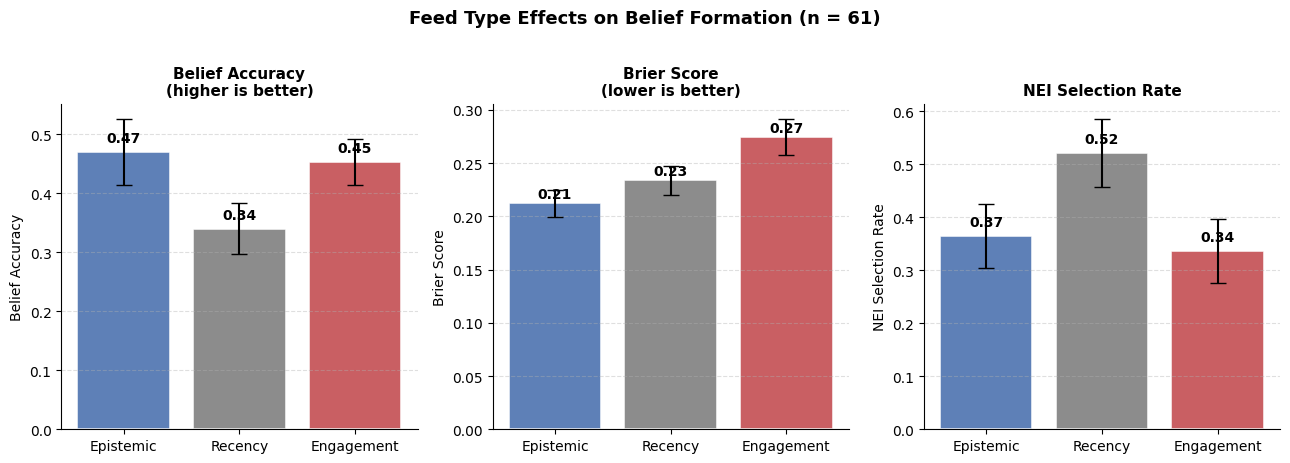

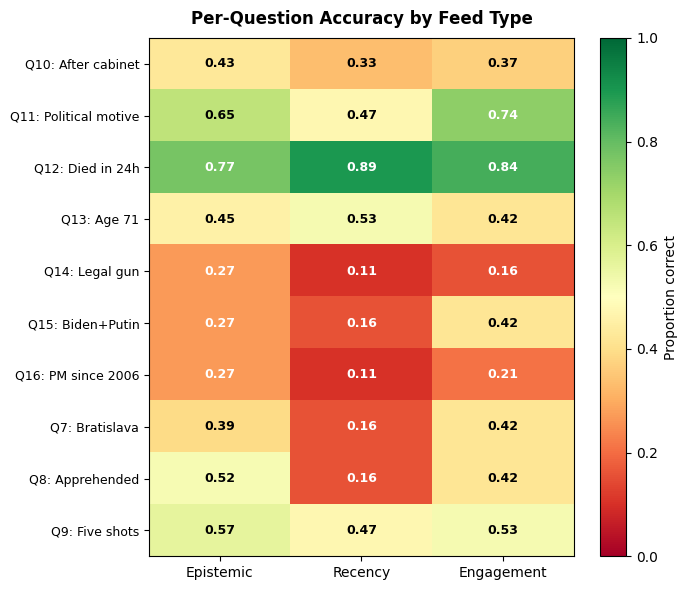

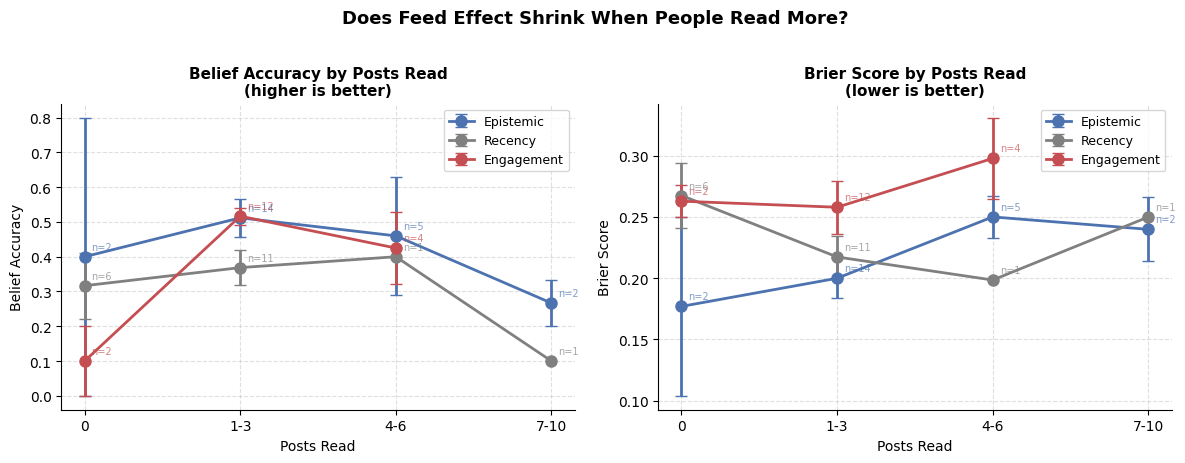


HEAVY-READER INTERACTION TEST

--- ACCURACY ---
  posts_read_ord: coef=-0.027, p=0.695
  C(Feed_Type, Treatment("Recency"))[T.Engagement]:posts_read_ord: coef=0.131, p=0.256
  C(Feed_Type, Treatment("Recency"))[T.Epistemic]:posts_read_ord: coef=-0.029, p=0.749
  Model R²: 0.105

--- BRIER ---
  posts_read_ord: coef=-0.019, p=0.313
  C(Feed_Type, Treatment("Recency"))[T.Engagement]:posts_read_ord: coef=0.042, p=0.195
  C(Feed_Type, Treatment("Recency"))[T.Epistemic]:posts_read_ord: coef=0.048, p=0.067
  Model R²: 0.189


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Consistent color scheme
feed_colors = {
    'Epistemic': '#4C72B0',   # blue
    'Recency':   '#808080',   # gray (neutral baseline)
    'Engagement':'#C44E52',   # red
}
feeds = ['Epistemic', 'Recency', 'Engagement']

# =========================================================
# PLOT 1: Main outcomes — accuracy, Brier, NEI rate
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (outcome, label, better) in zip(axes, [
    ('accuracy', 'Belief Accuracy', 'higher is better'),
    ('brier',    'Brier Score',     'lower is better'),
    ('nei_rate', 'NEI Selection Rate', ''),
]):
    means = [df[df['Feed Type']==f][outcome].mean() for f in feeds]
    sems  = [df[df['Feed Type']==f][outcome].sem()  for f in feeds]
    colors = [feed_colors[f] for f in feeds]
    bars = ax.bar(feeds, means, yerr=sems, capsize=6,
                  color=colors, edgecolor='white', linewidth=1.2, alpha=0.9)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sems)*0.3,
                f'{m:.2f}', ha='center', fontsize=10, fontweight='bold')
    title = label + (f'\n({better})' if better else '')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Feed Type Effects on Belief Formation (n = 61)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_main_outcomes.png', dpi=180, bbox_inches='tight')
plt.show()

# =========================================================
# PLOT 2: Per-question accuracy heatmap
# =========================================================
q_labels = {
    'Q7':  'Q7: Bratislava',
    'Q8':  'Q8: Apprehended',
    'Q9':  'Q9: Five shots',
    'Q10': 'Q10: After cabinet',
    'Q11': 'Q11: Political motive',
    'Q12': 'Q12: Died in 24h',
    'Q13': 'Q13: Age 71',
    'Q14': 'Q14: Legal gun',
    'Q15': 'Q15: Biden+Putin',
    'Q16': 'Q16: PM since 2006',
}

per_q_data = []
for q in ground_truth.keys():
    for feed in feeds:
        acc = df[df['Feed Type']==feed][f'{q}_correct'].mean()
        per_q_data.append({'Question': q_labels[q], 'Feed': feed, 'Accuracy': acc})
per_q_df = pd.DataFrame(per_q_data)
heatmap = per_q_df.pivot(index='Question', columns='Feed', values='Accuracy')
heatmap = heatmap[feeds]  # column order

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(heatmap.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(feeds)))
ax.set_xticklabels(feeds, fontsize=10)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index, fontsize=9)

for i in range(len(heatmap.index)):
    for j in range(len(feeds)):
        val = heatmap.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='black' if 0.3 < val < 0.7 else 'white', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Proportion correct')
ax.set_title('Per-Question Accuracy by Feed Type', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('plot_per_question.png', dpi=180, bbox_inches='tight')
plt.show()

# =========================================================
# PLOT 3: Heavy-reader interaction
# =========================================================
# Posts read × feed type interaction on accuracy and Brier
posts_labels = {0: '0', 1: '1-3', 2: '4-6', 3: '7-10'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (outcome, label, better) in zip(axes, [
    ('accuracy', 'Belief Accuracy', 'higher is better'),
    ('brier',    'Brier Score',     'lower is better'),
]):
    for feed in feeds:
        sub = df[df['Feed Type']==feed]
        grouped = sub.groupby('posts_read_ord')[outcome].agg(['mean', 'sem', 'count']).reset_index()
        ax.errorbar(grouped['posts_read_ord'], grouped['mean'], yerr=grouped['sem'],
                    marker='o', markersize=8, linewidth=2, capsize=4,
                    color=feed_colors[feed], label=feed)
        # Annotate counts
        for _, row in grouped.iterrows():
            ax.annotate(f'n={int(row["count"])}',
                        (row['posts_read_ord'], row['mean']),
                        textcoords='offset points', xytext=(5, 5),
                        fontsize=7, color=feed_colors[feed], alpha=0.7)
    ax.set_xticks(list(posts_labels.keys()))
    ax.set_xticklabels(list(posts_labels.values()))
    ax.set_xlabel('Posts Read')
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Posts Read\n({better})', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.4)

fig.suptitle('Does Feed Effect Shrink When People Read More?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_heavy_reader.png', dpi=180, bbox_inches='tight')
plt.show()

# =========================================================
# STATISTICAL TEST: Feed × posts read interaction
# =========================================================
import statsmodels.formula.api as smf

df_clean = df.rename(columns=lambda c: c.replace(' ', '_').replace(':', ''))
print("\n" + "=" * 55)
print("HEAVY-READER INTERACTION TEST")
print("=" * 55)
for outcome in ['accuracy', 'brier']:
    model = smf.ols(
        f'{outcome} ~ C(Feed_Type, Treatment("Recency")) * posts_read_ord',
        data=df_clean
    ).fit()
    print(f"\n--- {outcome.upper()} ---")
    # Just print the interaction terms
    for param, pval in zip(model.params.index, model.pvalues):
        if ':' in param or 'posts_read' in param:
            print(f"  {param}: coef={model.params[param]:.3f}, p={pval:.3f}")
    print(f"  Model R²: {model.rsquared:.3f}")

In [8]:
print("=" * 55)
print("DEMOGRAPHIC BREAKDOWN")
print("=" * 55)

# Original totals (before attention check exclusion)
# Re-read raw data to get full counts including excluded
epistemic_raw = pd.read_csv('epistemic.csv')
recency_raw = pd.read_csv('recency.csv')
engagement_raw = pd.read_csv('engagement.csv')
epistemic_raw['Feed Type'] = 'Epistemic'
recency_raw['Feed Type'] = 'Recency'
engagement_raw['Feed Type'] = 'Engagement'
raw = pd.concat([epistemic_raw, recency_raw, engagement_raw], ignore_index=True)

n_total = len(raw)
n_passed = (raw['Q23: Attention'] == 'Somewhat agree').sum()
n_excluded = n_total - n_passed

print(f"\nParticipation:")
print(f"  Total responses collected:     {n_total}")
print(f"  Failed attention check:        {n_excluded}")
print(f"  Included in analysis:          {n_passed}")
print(f"  Exclusion rate:                {n_excluded/n_total*100:.1f}%")

print(f"\nResponses per feed (after exclusion):")
print(df['Feed Type'].value_counts().to_string())

print(f"\nAge distribution:")
age_counts = df['Q24: Age'].value_counts().sort_index()
for age, n in age_counts.items():
    print(f"  {age}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nCountry of residence:")
country_counts = df['Q26: Country'].value_counts()
for country, n in country_counts.items():
    print(f"  {country}: {n} ({n/len(df)*100:.1f}%)")

us_count = df['Q26: Country'].str.contains('United States|USA|US|America',
                                             case=False, na=False).sum()
intl_count = len(df) - us_count
print(f"\n  US-based:        {us_count} ({us_count/len(df)*100:.1f}%)")
print(f"  International:   {intl_count} ({intl_count/len(df)*100:.1f}%)")

print(f"\nEducation:")
edu_counts = df['Q25: Education'].value_counts()
for edu, n in edu_counts.items():
    print(f"  {edu}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nPrimary news source:")
news_counts = df['Q3: News Source'].value_counts()
for src, n in news_counts.items():
    print(f"  {src}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nInternational news frequency:")
intl_freq = df['Q4: International News Frequency'].value_counts()
for freq, n in intl_freq.items():
    print(f"  {freq}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nPolitical orientation (1=very liberal, 7=very conservative):")
pol = pd.to_numeric(df['Q27: Politics'], errors='coerce')
print(f"  Mean: {pol.mean():.2f}, Median: {pol.median():.1f}")
print(f"  Distribution: {pol.value_counts().sort_index().to_dict()}")
pnts = (df['Q27: Politics'] == 'Prefer not to say').sum()
print(f"  Prefer not to say: {pnts}")

print(f"\nPrior familiarity with Fico shooting:")
fam = df['Q1: Familiarity'].describe()
print(f"  Mean: {fam['mean']:.2f}, Median: {df['Q1: Familiarity'].median()}")
print(f"  High familiarity (4-5): {(df['Q1: Familiarity'] >= 4).sum()} ({(df['Q1: Familiarity'] >= 4).mean()*100:.1f}%)")
print(f"  Followed prior coverage: {(df['Q2: Prior Knowledge'] == 'Yes').sum()}")

DEMOGRAPHIC BREAKDOWN

Participation:
  Total responses collected:     72
  Failed attention check:        9
  Included in analysis:          63
  Exclusion rate:                12.5%

Responses per feed (after exclusion):
Feed Type
Epistemic     23
Recency       19
Engagement    19

Age distribution:
  18-24: 26 (42.6%)
  25-34: 24 (39.3%)
  35-44: 1 (1.6%)
  45-54: 5 (8.2%)
  55-64: 3 (4.9%)
  65+: 2 (3.3%)

Country of residence:
  United States: 39 (63.9%)
  United States : 4 (6.6%)
  US: 4 (6.6%)
  Norway: 3 (4.9%)
  Norway : 2 (3.3%)
  South Korea: 2 (3.3%)
  US and China: 1 (1.6%)
  USA: 1 (1.6%)
  INDIA: 1 (1.6%)
  India: 1 (1.6%)
  us: 1 (1.6%)

  US-based:        50 (82.0%)
  International:   11 (18.0%)

Education:
  Bachelors: 29 (47.5%)
  Masters: 17 (27.9%)
  Some college: 7 (11.5%)
  Doctoral: 4 (6.6%)
  HS: 3 (4.9%)
  <HS: 1 (1.6%)

Primary news source:
  Social media: 32 (52.5%)
  Online news: 21 (34.4%)
  Podcasts/radio: 6 (9.8%)
  Newspapers: 1 (1.6%)

International ne

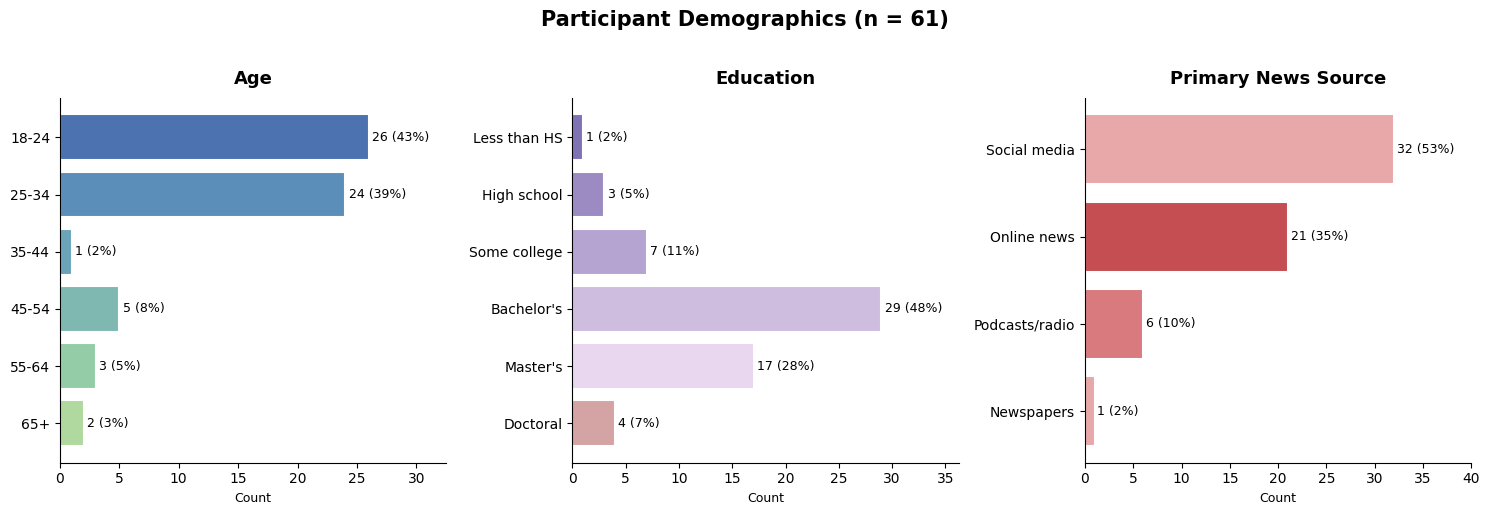

In [9]:
import matplotlib.pyplot as plt

age_colors = ['#4C72B0', '#5B8FB9', '#6BA4B8', '#7FB8B0', '#95CCA8', '#B0D99F']
edu_colors = ['#8172B3', '#9B8BC2', '#B5A4D1', '#CFBDE0', '#E9D6EF', '#D4A4A4']
news_colors = ['#C44E52', '#D97B7E', '#E8A8AA']

def clean_education(s):
    mapping = {'<HS': 'Less than HS', 'HS': 'High school',
               'Some college': 'Some college', 'Bachelors': "Bachelor's",
               'Masters': "Master's", 'Doctoral': 'Doctoral'}
    return mapping.get(s, s)
df['education_clean'] = df['Q25: Education'].apply(clean_education)

def draw_hbar(ax, counts, colors, title):
    total = counts.sum()
    # Reverse for top-to-bottom reading order
    counts = counts[::-1]
    pcts = counts / total * 100
    bars = ax.barh(range(len(counts)), counts.values,
                   color=colors[:len(counts)][::-1],
                   edgecolor='white', linewidth=1.5)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=10)
    ax.set_xlabel('Count', fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    # Annotate with count and percentage
    for bar, count, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{int(count)} ({pct:.0f}%)',
                va='center', fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, counts.max() * 1.25)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_counts = df['Q24: Age'].value_counts().reindex(age_order).dropna().astype(int)
draw_hbar(axes[0], age_counts, age_colors, 'Age')

edu_order = ['Less than HS', 'High school', 'Some college',
             "Bachelor's", "Master's", 'Doctoral']
edu_counts = df['education_clean'].value_counts().reindex(edu_order).dropna().astype(int)
draw_hbar(axes[1], edu_counts, edu_colors, 'Education')

news_counts = df['Q3: News Source'].value_counts()
draw_hbar(axes[2], news_counts, news_colors, 'Primary News Source')

fig.suptitle(f'Participant Demographics (n = {len(df)})',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_demographics.png', dpi=180, bbox_inches='tight')
plt.show()

In [10]:
from scipy import stats

print("=" * 60)
print("PERCEIVED FEED EFFECTS (Q17–Q22)")
print("=" * 60)

perception_cols = [
    ('Q17: Trust',           'Trustworthiness'),
    ('Q18: Bias',            'Perceived bias'),
    ('Q19: Emotion',         'Emotional activation'),
    ('Q20: Contradiction',   'Perceived contradictions'),
    ('Q21: Charged Language','Charged language'),
    ('Q22: Context',         'Contextual depth'),
]

feeds = ['Epistemic', 'Recency', 'Engagement']

for col, label in perception_cols:
    # Coerce to numeric in case it's stored as string
    df[col] = pd.to_numeric(df[col], errors='coerce')
    groups = [df[df['Feed Type']==f][col].dropna() for f in feeds]
    f_stat, p = stats.f_oneway(*groups)
    means = {feed: g.mean() for feed, g in zip(feeds, groups)}
    sds = {feed: g.std() for feed, g in zip(feeds, groups)}
    print(f"\n{label} ({col}):")
    print(f"  F = {f_stat:.3f}, p = {p:.3f}")
    for feed in feeds:
        print(f"  {feed}: mean={means[feed]:.2f}, sd={sds[feed]:.2f}")

PERCEIVED FEED EFFECTS (Q17–Q22)

Trustworthiness (Q17: Trust):
  F = 1.969, p = 0.149
  Epistemic: mean=4.17, sd=1.27
  Recency: mean=4.16, sd=1.74
  Engagement: mean=5.00, sd=1.56

Perceived bias (Q18: Bias):
  F = 0.579, p = 0.564
  Epistemic: mean=3.35, sd=1.47
  Recency: mean=2.95, sd=1.87
  Engagement: mean=2.84, sd=1.54

Emotional activation (Q19: Emotion):
  F = 1.052, p = 0.356
  Epistemic: mean=1.91, sd=1.41
  Recency: mean=1.32, sd=1.73
  Engagement: mean=2.05, sd=1.90

Perceived contradictions (Q20: Contradiction):
  F = 0.810, p = 0.450
  Epistemic: mean=2.74, sd=1.51
  Recency: mean=2.11, sd=1.41
  Engagement: mean=2.63, sd=2.09

Charged language (Q21: Charged Language):
  F = 2.171, p = 0.123
  Epistemic: mean=3.61, sd=1.95
  Recency: mean=2.79, sd=1.75
  Engagement: mean=2.47, sd=1.78

Contextual depth (Q22: Context):
  F = 2.357, p = 0.104
  Epistemic: mean=3.65, sd=1.67
  Recency: mean=2.63, sd=1.42
  Engagement: mean=2.89, sd=1.66


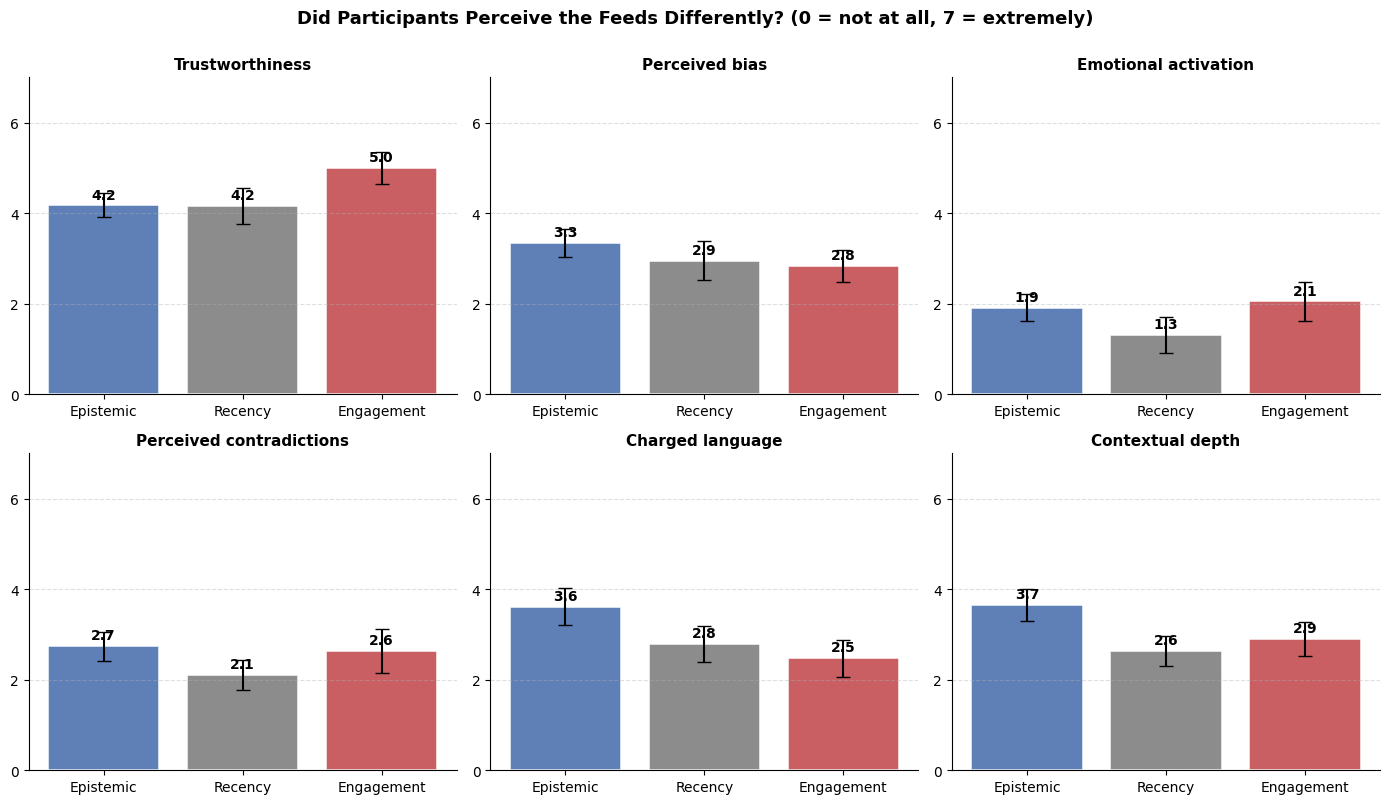

In [11]:
import matplotlib.pyplot as plt
import numpy as np

feed_colors = {'Epistemic': '#4C72B0', 'Recency': '#808080', 'Engagement': '#C44E52'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (col, label) in zip(axes.flatten(), perception_cols):
    means = [df[df['Feed Type']==f][col].mean() for f in feeds]
    sems  = [df[df['Feed Type']==f][col].sem() for f in feeds]
    colors = [feed_colors[f] for f in feeds]
    bars = ax.bar(feeds, means, yerr=sems, capsize=5,
                  color=colors, edgecolor='white', linewidth=1.2, alpha=0.9)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{m:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 7)
    ax.set_yticks([0, 2, 4, 6])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Did Participants Perceive the Feeds Differently? (0 = not at all, 7 = extremely)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plot_perceptions.png', dpi=180, bbox_inches='tight')
plt.show()

In [12]:
print("=" * 60)
print("POSTS READ DISTRIBUTION BY FEED")
print("=" * 60)

posts_labels = {0: '0 (none)', 1: '1-3', 2: '4-6', 3: '7-10'}

# Count and percentage by feed
for feed in ['Epistemic', 'Recency', 'Engagement']:
    sub = df[df['Feed Type'] == feed]
    print(f"\n{feed} (n={len(sub)}):")
    vc = sub['posts_read_ord'].value_counts().sort_index()
    for k, label in posts_labels.items():
        count = vc.get(k, 0)
        pct = count / len(sub) * 100
        print(f"  {label}: {count} ({pct:.1f}%)")
    zero_readers = (sub['posts_read_ord'] == 0).sum()
    print(f"  → Non-readers (0 posts): {zero_readers} ({zero_readers/len(sub)*100:.1f}%)")

# Overall non-reader rate
print(f"\nOverall non-reader rate: "
      f"{(df['posts_read_ord']==0).sum()}/{len(df)} "
      f"({(df['posts_read_ord']==0).mean()*100:.1f}%)")

# Chi-square test: is posts read distribution different across feeds?
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['Feed Type'], df['posts_read_ord'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test (posts read distribution across feeds):")
print(f"  χ² = {chi2:.3f}, df = {dof}, p = {p:.3f}")
print("\nCrosstab (counts):")
print(contingency)

POSTS READ DISTRIBUTION BY FEED

Epistemic (n=23):
  0 (none): 2 (8.7%)
  1-3: 14 (60.9%)
  4-6: 5 (21.7%)
  7-10: 2 (8.7%)
  → Non-readers (0 posts): 2 (8.7%)

Recency (n=19):
  0 (none): 6 (31.6%)
  1-3: 11 (57.9%)
  4-6: 1 (5.3%)
  7-10: 1 (5.3%)
  → Non-readers (0 posts): 6 (31.6%)

Engagement (n=19):
  0 (none): 2 (10.5%)
  1-3: 12 (63.2%)
  4-6: 4 (21.1%)
  7-10: 0 (0.0%)
  → Non-readers (0 posts): 2 (10.5%)

Overall non-reader rate: 10/61 (16.4%)

Chi-square test (posts read distribution across feeds):
  χ² = 7.566, df = 6, p = 0.272

Crosstab (counts):
posts_read_ord  0.0  1.0  2.0  3.0
Feed Type                         
Engagement        2   12    4    0
Epistemic         2   14    5    2
Recency           6   11    1    1


In [13]:
print("=" * 60)
print("SENSITIVITY ANALYSIS: EXCLUDING NON-READERS")
print("=" * 60)

# Exclude participants who read 0 posts
df_readers = df[df['posts_read_ord'] > 0].copy()

print(f"\nN after excluding non-readers: {len(df_readers)}")
print(df_readers['Feed Type'].value_counts())

print("\n--- Outcome summary (readers only) ---")
print(df_readers.groupby('Feed Type')[['accuracy', 'brier', 'nei_rate']]
      .agg(['mean', 'std']).round(3))

print("\n--- Brier Score (readers only) ---")
groups = [df_readers[df_readers['Feed Type']==f]['brier'].dropna() 
          for f in ['Epistemic', 'Recency', 'Engagement']]
f_stat, p = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p:.3f}")

pairs = [('Epistemic','Engagement'), ('Epistemic','Recency'), 
         ('Engagement','Recency')]
for a, b in pairs:
    g1 = df_readers[df_readers['Feed Type']==a]['brier'].dropna()
    g2 = df_readers[df_readers['Feed Type']==b]['brier'].dropna()
    # t, p_t = stats.ttest_ind(g1, g2)
    t, p_t = stats.ttest_ind(g1, g2, equal_var=False)
    pooled_sd = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    d = (g1.mean() - g2.mean()) / pooled_sd
    print(f"  {a} vs {b}: t={t:.3f}, p={p_t:.3f}, d={d:.3f}")

print("\n--- Accuracy (readers only) ---")
groups = [df_readers[df_readers['Feed Type']==f]['accuracy'].dropna() 
          for f in ['Epistemic', 'Recency', 'Engagement']]
f_stat, p = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p:.3f}")

for a, b in pairs:
    g1 = df_readers[df_readers['Feed Type']==a]['accuracy'].dropna()
    g2 = df_readers[df_readers['Feed Type']==b]['accuracy'].dropna()
    # t, p_t = stats.ttest_ind(g1, g2)
    t, p_t = stats.ttest_ind(g1, g2, equal_var=False)
    pooled_sd = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    d = (g1.mean() - g2.mean()) / pooled_sd
    print(f"  {a} vs {b}: t={t:.3f}, p={p_t:.3f}, d={d:.3f}")

print("\n--- NEI Rate (readers only) ---")
groups = [df_readers[df_readers['Feed Type']==f]['nei_rate'].dropna() 
          for f in ['Epistemic', 'Recency', 'Engagement']]
f_stat, p = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p:.3f}")

SENSITIVITY ANALYSIS: EXCLUDING NON-READERS

N after excluding non-readers: 50
Feed Type
Epistemic     21
Engagement    16
Recency       13
Name: count, dtype: int64

--- Outcome summary (readers only) ---
           accuracy         brier        nei_rate       
               mean    std   mean    std     mean    std
Feed Type                                               
Engagement    0.494  0.124  0.268  0.073    0.288  0.196
Epistemic     0.476  0.248  0.216  0.058    0.348  0.258
Recency       0.350  0.171  0.218  0.054    0.523  0.242

--- Brier Score (readers only) ---
ANOVA: F=3.716, p=0.032
  Epistemic vs Engagement: t=-2.366, p=0.025, d=-0.797
  Epistemic vs Recency: t=-0.139, p=0.890, d=-0.049
  Engagement vs Recency: t=2.103, p=0.045, d=0.773

--- Accuracy (readers only) ---
ANOVA: F=2.251, p=0.117
  Epistemic vs Engagement: t=-0.281, p=0.780, d=-0.090
  Epistemic vs Recency: t=1.745, p=0.091, d=0.589
  Engagement vs Recency: t=2.528, p=0.019, d=0.959

--- NEI Rate (reader

In [14]:
from scipy.stats import ttest_ind
g1 = df[df['Feed Type']=='Epistemic']['brier'].dropna()
g2 = df[df['Feed Type']=='Engagement']['brier'].dropna()
result = ttest_ind(g1, g2, equal_var=False)
print(f"t = {result.statistic:.3f}")
print(f"p = {result.pvalue:.3f}")
print(f"df = {result.df:.1f}")

t = -2.961
p = 0.005
df = 34.8


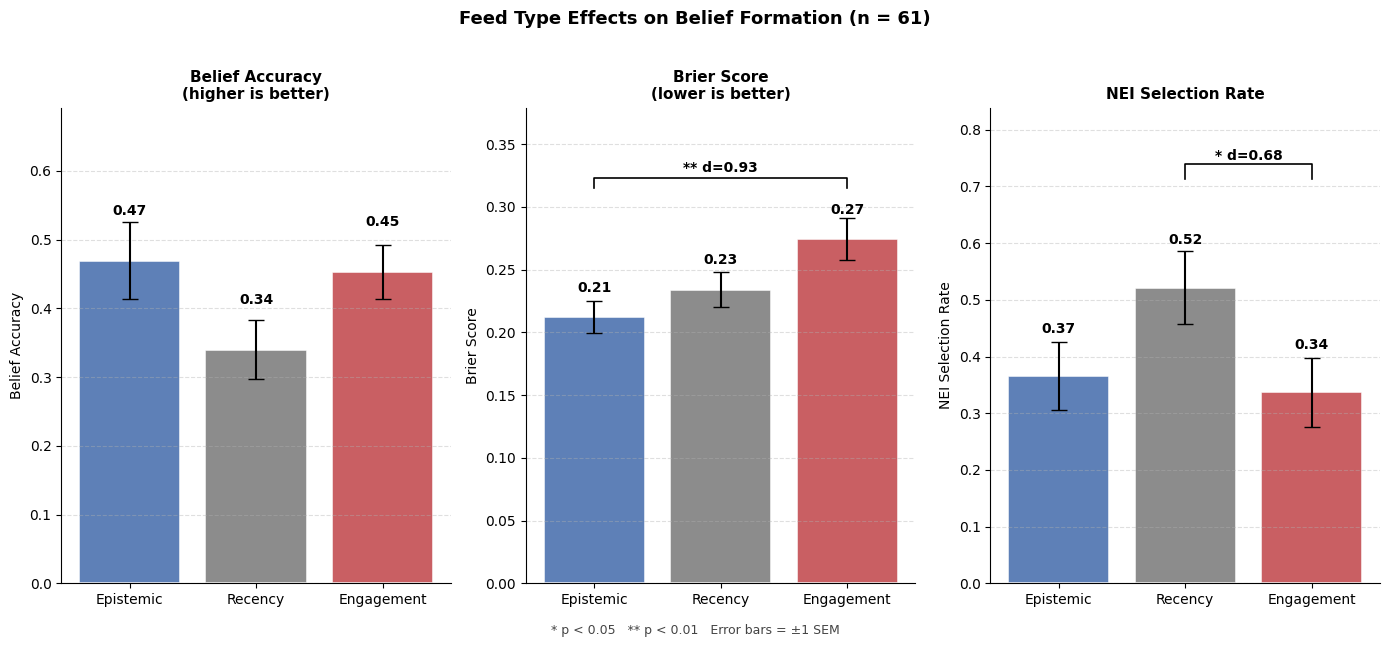

In [22]:
import matplotlib.pyplot as plt
import numpy as np

feed_colors = {
    'Epistemic':  '#4C72B0',
    'Recency':    '#808080',
    'Engagement': '#C44E52',
}
feeds = ['Epistemic', 'Recency', 'Engagement']

def add_bracket(ax, x1, x2, y, h, text, fontsize=10):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y+h+0.002, text,
            ha='center', va='bottom', fontsize=fontsize, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, (outcome, label, better) in zip(axes, [
    ('accuracy', 'Belief Accuracy',   'higher is better'),
    ('brier',    'Brier Score',        'lower is better'),
    ('nei_rate', 'NEI Selection Rate', ''),
]):
    means = [df[df['Feed Type']==f][outcome].mean() for f in feeds]
    sems  = [df[df['Feed Type']==f][outcome].sem()  for f in feeds]
    colors = [feed_colors[f] for f in feeds]

    bars = ax.bar(feeds, means, yerr=sems, capsize=6,
                  color=colors, edgecolor='white',
                  linewidth=1.2, alpha=0.9)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(sems)*1.2,
                f'{m:.2f}', ha='center', fontsize=10, fontweight='bold')

    title = label + (f'\n({better})' if better else '')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    if outcome == 'brier':
        h = 0.008
        b1_y = 0.315
        # Only Epistemic vs Engagement significant (p=.005, d=0.93)
        add_bracket(ax, 0, 2, b1_y, h, '** d=0.93')
        ax.set_ylim(0, b1_y + h * 8)

    elif outcome == 'accuracy':
        # No significant pairwise comparisons
        ax.set_ylim(0, max(means) + max(sems) * 4)

    elif outcome == 'nei_rate':
        h = 0.025
        b1_y = max(means) + max(sems) * 3
        # Engagement (x=2) vs Recency (x=1) significant (p=.044, d=0.68)
        add_bracket(ax, 1, 2, b1_y, h, '* d=0.68')
        ax.set_ylim(0, b1_y + h * 5)

fig.text(0.5, -0.02,
         '* p < 0.05   ** p < 0.01   Error bars = ±1 SEM',
         ha='center', fontsize=9, color='#444444')

fig.suptitle('Feed Type Effects on Belief Formation (n = 61)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_main_outcomes_final.png', dpi=180, bbox_inches='tight')
plt.show()

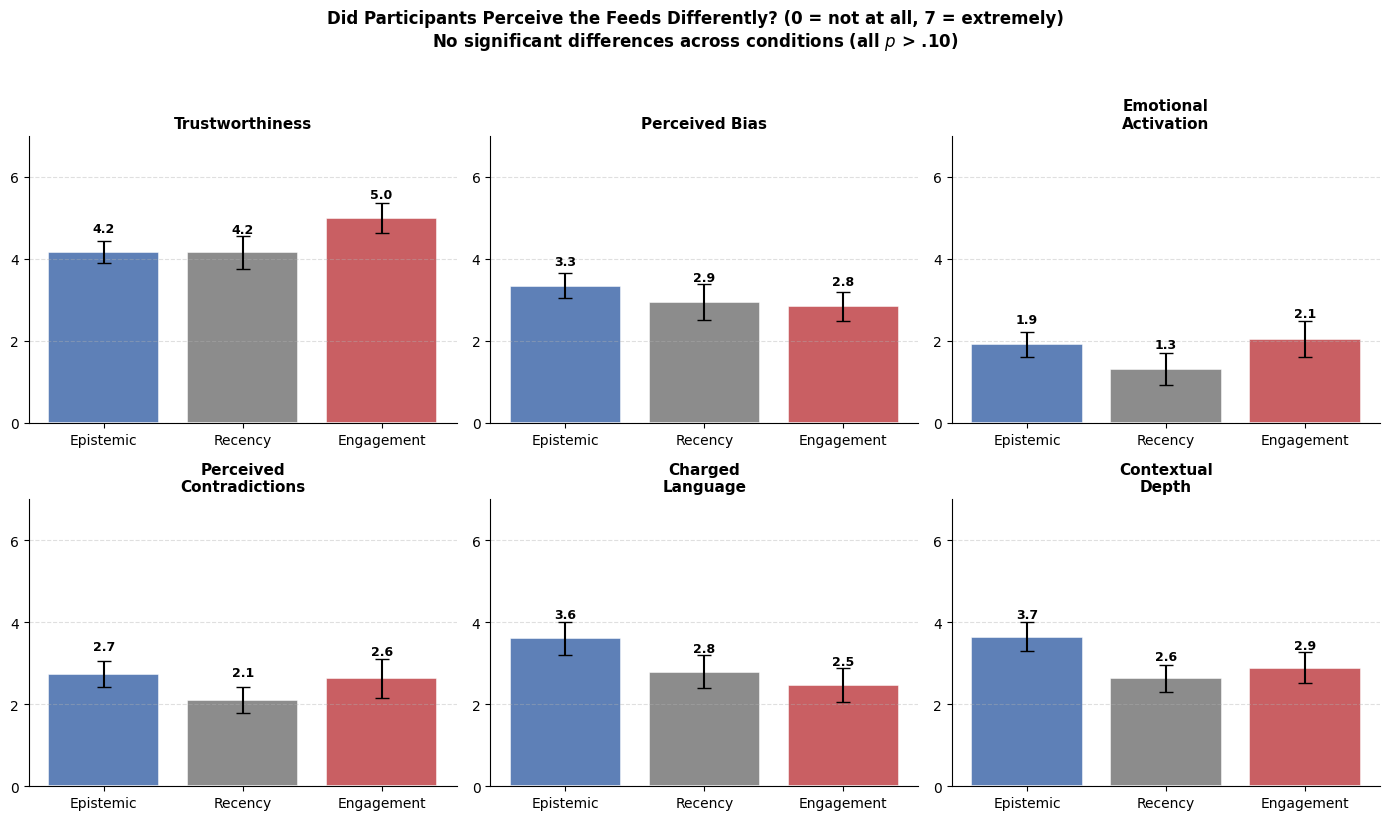

In [23]:
import matplotlib.pyplot as plt
import numpy as np

feed_colors = {
    'Epistemic':  '#4C72B0',
    'Recency':    '#808080',
    'Engagement': '#C44E52',
}
feeds = ['Epistemic', 'Recency', 'Engagement']

perception_cols = [
    ('Q17: Trust',           'Trustworthiness'),
    ('Q18: Bias',            'Perceived Bias'),
    ('Q19: Emotion',         'Emotional\nActivation'),
    ('Q20: Contradiction',   'Perceived\nContradictions'),
    ('Q21: Charged Language','Charged\nLanguage'),
    ('Q22: Context',         'Contextual\nDepth'),
]

for col, _ in perception_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (col, label) in zip(axes.flatten(), perception_cols):
    means = [df[df['Feed Type']==f][col].mean() for f in feeds]
    sems  = [df[df['Feed Type']==f][col].sem()  for f in feeds]
    colors = [feed_colors[f] for f in feeds]

    bars = ax.bar(feeds, means, yerr=sems, capsize=5,
                  color=colors, edgecolor='white',
                  linewidth=1.2, alpha=0.9)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(sems)*1.2,
                f'{m:.1f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 7)
    ax.set_yticks([0, 2, 4, 6])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Did Participants Perceive the Feeds Differently? (0 = not at all, 7 = extremely)\n'
    'No significant differences across conditions (all $p$ > .10)',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plot_perceptions_final.png', dpi=180, bbox_inches='tight')
plt.show()

In [16]:
from scipy.stats import ttest_ind

print("Exact Welch's t-test degrees of freedom:")
print()

comparisons = [
    ('Epistemic', 'Engagement', 'brier',    'Epistemic vs Engagement — Brier'),
    ('Epistemic', 'Recency',    'brier',    'Epistemic vs Recency — Brier'),
    ('Engagement','Recency',    'accuracy', 'Engagement vs Recency — Accuracy'),
]

for a, b, outcome, label in comparisons:
    g1 = df[df['Feed Type']==a][outcome].dropna()
    g2 = df[df['Feed Type']==b][outcome].dropna()
    result = ttest_ind(g1, g2, equal_var=False)
    print(f"{label}:")
    print(f"  t = {result.statistic:.3f}")
    print(f"  df = {result.df:.1f}")
    print(f"  p = {result.pvalue:.3f}")
    print()

Exact Welch's t-test degrees of freedom:

Epistemic vs Engagement — Brier:
  t = -2.961
  df = 34.8
  p = 0.005

Epistemic vs Recency — Brier:
  t = -1.155
  df = 38.5
  p = 0.255

Engagement vs Recency — Accuracy:
  t = 1.944
  df = 35.7
  p = 0.060



In [17]:
print("Sensitivity analysis — readers only df values:")
print()
df_readers = df[df['posts_read_ord'] > 0].copy()

comparisons = [
    ('Epistemic', 'Engagement', 'brier',    'Epistemic vs Engagement — Brier'),
    ('Epistemic', 'Recency',    'brier',    'Epistemic vs Recency — Brier'),
    ('Engagement','Recency',    'brier',    'Engagement vs Recency — Brier'),
    ('Engagement','Recency',    'accuracy', 'Engagement vs Recency — Accuracy'),
    ('Epistemic', 'Recency',    'accuracy', 'Epistemic vs Recency — Accuracy'),
    ('Epistemic', 'Engagement', 'accuracy', 'Epistemic vs Engagement — Accuracy'),
]

for a, b, outcome, label in comparisons:
    g1 = df_readers[df_readers['Feed Type']==a][outcome].dropna()
    g2 = df_readers[df_readers['Feed Type']==b][outcome].dropna()
    result = ttest_ind(g1, g2, equal_var=False)
    print(f"{label}: t={result.statistic:.3f}, df={result.df:.1f}, p={result.pvalue:.3f}")

Sensitivity analysis — readers only df values:

Epistemic vs Engagement — Brier: t=-2.366, df=28.0, p=0.025
Epistemic vs Recency — Brier: t=-0.139, df=26.8, p=0.890
Engagement vs Recency — Brier: t=2.103, df=26.8, p=0.045
Engagement vs Recency — Accuracy: t=2.528, df=21.3, p=0.019
Epistemic vs Recency — Accuracy: t=1.745, df=31.5, p=0.091
Epistemic vs Engagement — Accuracy: t=-0.281, df=30.8, p=0.780
